### interpretation of the whole notebook results and summary of key findings:
- Temporal patterns: We see clear rush hour peaks on weekdays, with a smaller midday peak. Weekends have a more even distribution but still show higher usage during the day.
- Geographic analysis: Certain stations and districts are much more popular, likely due to proximity to transit hubs, commercial areas, or tourist attractions. There are also strong intra-district flows in some areas, while others have more inter-district trips.
- Station network: A few stations act as major hubs with many unique destinations, while most stations have a more limited set of routes. Some popular routes are likely influenced by nearby attractions or transit connections.
- Trip duration: The distribution is heavily skewed with a long tail of very long trips. The median is much lower than the mean, indicating many short trips and a few very long ones. Outliers are present but not dominant.
- Short trips: A significant portion of trips are under 2 minutes, with many being same-station returns. This could indicate quick returns or potential data issues (e.g., accidental check-ins).
- Long trips: There are also trips over 12 hours, which may indicate lost bikes, rentals that span multiple days, or data errors. These long trips are relatively rare but can significantly affect average duration statistics.    
- Station-specific analysis: For a station like "cyclo", we can see its specific usage patterns, popular routes, and duration characteristics. This can help identify if it's primarily a starting point, an endpoint, or both, and how it fits into the overall network.
Overall, the analysis provides a comprehensive view of the BIXI bike-share system, highlighting key trends, popular stations and routes, and areas for potential improvement (e.g., addressing short trip patterns
or investigating long trip outliers). The insights can inform operational decisions, marketing strategies, and future data collection efforts."""

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ All libraries loaded successfully!")
print(f"DuckDB version: {duckdb.__version__}")

✓ All libraries loaded successfully!
DuckDB version: 1.4.4


In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("TripAnalysis").getOrCreate()
spark.conf.set("spark.sql.session.timeZone", "America/Toronto")
print("Spark version:", spark.version)

# Point to the parent 'rides' folder – Spark will discover the ride_year partitions
rides_df = spark.read.parquet("../../data/silver/rides/", unionByName=True)

# Check schema and partition columns
rides_df.printSchema()
rides_df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/21 14:59:10 WARN Utils: Your hostname, users-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.249.217.15 instead (on interface en0)
26/03/21 14:59:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/21 14:59:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


root
 |-- end_station_key: string (nullable = true)
 |-- start_station_key: string (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_district: string (nullable = true)
 |-- start_station_latitude: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_district: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_longitude: double (nullable = true)
 |-- start_time_ms: timestamp (nullable = true)
 |-- end_time_ms: timestamp (nullable = true)
 |-- start_station_name_norm: string (nullable = true)
 |-- end_station_name_norm: string (nullable = true)
 |-- start_coord_key: string (nullable = true)
 |-- end_coord_key: string (nullable = true)
 |-- start_canonical_station_id: string (nullable = true)
 |-- end_canonical_station_id: string (nullable = true)
 |-- ride_year: integer (nullable = true)



+--------------------+--------------------+--------------------+----------------------+----------------------+-----------------------+--------------------+--------------------+--------------------+---------------------+-------------------+-------------------+-----------------------+---------------------+--------------------+--------------------+--------------------------+------------------------+---------+
|     end_station_key|   start_station_key|  start_station_name|start_station_district|start_station_latitude|start_station_longitude|    end_station_name|end_station_district|end_station_latitude|end_station_longitude|      start_time_ms|        end_time_ms|start_station_name_norm|end_station_name_norm|     start_coord_key|       end_coord_key|start_canonical_station_id|end_canonical_station_id|ride_year|
+--------------------+--------------------+--------------------+----------------------+----------------------+-----------------------+--------------------+--------------------+----

In [ ]:
rides_df.select("ride_year").distinct().show()  

+---------+
|ride_year|
+---------+
|     2024|
|     2025|
|     2026|
+---------+



## Descriptive EDA (first layer)

In [ ]:
\

IndentationError: unindent does not match any outer indentation level (<string>, line 54)

<Axes: xlabel='date'>

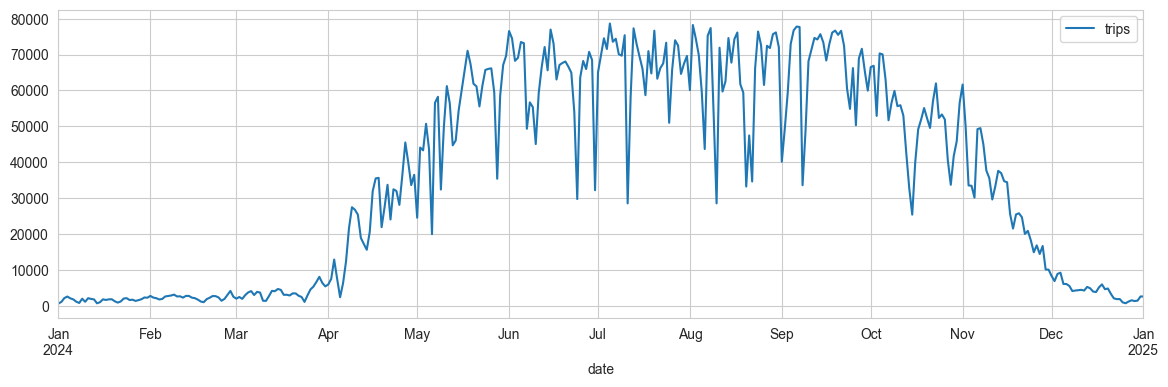

In [ ]:
# Daily trip count
daily = duckdb.sql("""
    SELECT DATE(to_timestamp(start_time_ms/1000.0)) as date, COUNT(*) as trips
    FROM read_parquet("../../data/**/*.parquet")  
    GROUP BY date ORDER BY date
""").df()
daily.plot(x='date', y='trips', figsize=(14,4))

<Axes: xlabel='hour'>

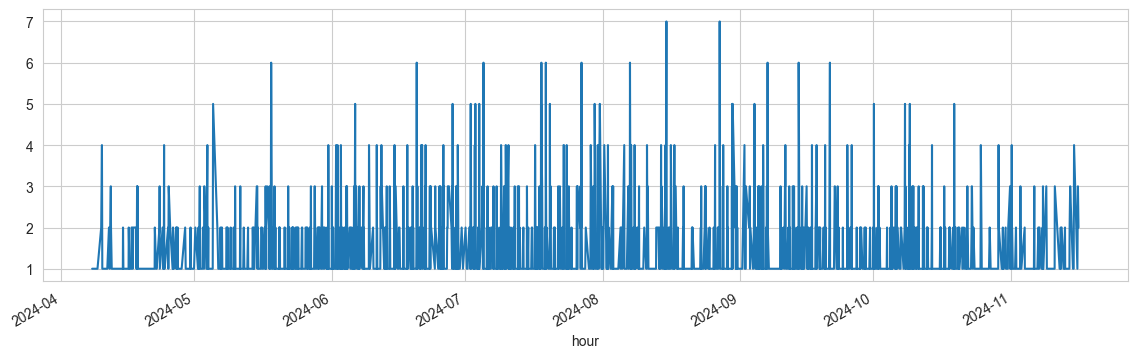

In [ ]:
# Hourly trips for station of name "Stinson / Montpellier"
station_17 = duckdb.sql("""
    SELECT DATE_TRUNC('hour', to_timestamp(start_time_ms/1000.0)) as hour,
           COUNT(*) as trips
    FROM read_parquet('../../data/**/*.parquet')
    WHERE start_station_name = 'Stinson / Montpellier'
    GROUP BY hour ORDER BY hour
""").df()
station_17.set_index('hour')['trips'].plot(figsize=(14,4))

In [ ]:
df_temp 

,hour_of_day,day_of_week,trip_count,avg_duration_ms,day_name
0,0,0,119654,1.038333e+06,Sunday
1,0,1,108442,1.095484e+06,Monday
2,0,2,87575,9.802836e+05,Tuesday
3,0,3,95396,9.866949e+05,Wednesday
4,0,4,92592,9.803685e+05,Thursday
...,...,...,...,...,...
163,23,2,77625,9.398296e+05,Tuesday
164,23,3,78366,9.426410e+05,Wednesday
165,23,4,78409,1.050573e+06,Thursday
166,23,5,88777,9.038912e+05,Friday


In [ ]:
df_top_start

,start_station_name,start_station_district,cnt
0,Métro Mont-Royal (Utilités publiques / Rivard),Le Plateau-Mont-Royal,117746
1,du Mont-Royal / Clark,Le Plateau-Mont-Royal,107638
2,Laurier / St-Denis,Le Plateau-Mont-Royal,84152
3,des Pins / St-Laurent,Le Plateau-Mont-Royal,79154
4,Marquette / du Mont-Royal,Le Plateau-Mont-Royal,78799
5,Métro Atwater (Atwater / Ste-Catherine),Ville-Marie,67032
6,Métro Peel (de Maisonneuve / Stanley),Ville-Marie,65118
7,Laurier / de Brébeuf,Le Plateau-Mont-Royal,62723
8,Émile-Duployé / Sherbrooke,Le Plateau-Mont-Royal,60132
9,Métro Papineau (Dorion / De Maisonneuve),Ville-Marie,59050


In [7]:
df_top_end

,end_station_name,end_station_district,cnt
0,Métro Mont-Royal (Utilités publiques / Rivard),Le Plateau-Mont-Royal,110896
1,du Mont-Royal / Clark,Le Plateau-Mont-Royal,94981
2,de la Commune / Place Jacques-Cartier,Ville-Marie,80967
3,Marquette / du Mont-Royal,Le Plateau-Mont-Royal,76797
4,des Pins / St-Laurent,Le Plateau-Mont-Royal,72992
5,None,None,72461
6,Métro Papineau (Dorion / De Maisonneuve),Ville-Marie,71563
7,Laurier / St-Denis,Le Plateau-Mont-Royal,71121
8,Métro Peel (de Maisonneuve / Stanley),Ville-Marie,65161
9,Laurier / de Brébeuf,Le Plateau-Mont-Royal,61736


In [8]:
df_district

,trip_type,trip_count,avg_duration_ms
0,Intra-District,7015689,7.264028e+05
1,Inter-District,6259637,1.332450e+06


In [9]:
df_dist_pop

,start_station_district,trip_count,num_stations,num_destinations
0,Le Plateau-Mont-Royal,4494275,195,1102
1,Ville-Marie,3321543,214,1093
2,Rosemont - La Petite-Patrie,1658482,127,1074
3,Le Sud-Ouest,967349,79,992
4,Villeray—Saint-Michel—Parc-Extension,663220,78,1042
5,Mercier - Hochelaga-Maisonneuve,529335,60,989
6,Côte-des-Neiges - Notre-Dame-de-Grâce,502272,66,1031
7,Verdun,299177,38,835
8,Outremont,213563,26,965
9,Ahuntsic-Cartierville,192387,40,945


In [10]:
df_flows

,start_station_district,end_station_district,trip_count
0,Le Plateau-Mont-Royal,Le Plateau-Mont-Royal,2567118
1,Ville-Marie,Ville-Marie,1905522
2,Le Plateau-Mont-Royal,Ville-Marie,1021117
3,Rosemont - La Petite-Patrie,Rosemont - La Petite-Patrie,693952
4,Ville-Marie,Le Plateau-Mont-Royal,596045
5,Le Sud-Ouest,Le Sud-Ouest,509205
6,Le Plateau-Mont-Royal,Rosemont - La Petite-Patrie,452895
7,Rosemont - La Petite-Patrie,Le Plateau-Mont-Royal,452661
8,Ville-Marie,Le Sud-Ouest,415659
9,Mercier - Hochelaga-Maisonneuve,Mercier - Hochelaga-Maisonneuve,295464


In [11]:
df_routes

,start_station_name,end_station_name,route_count,avg_duration_ms
0,Parc Jean-Drapeau (Chemin Macdonald),Parc Jean-Drapeau (Chemin Macdonald),12410,2.245331e+06
1,Métro Mont-Royal (Utilités publiques / Rivard),Marquette / du Mont-Royal,5058,4.195134e+05
2,Marquette / du Mont-Royal,Métro Mont-Royal (Utilités publiques / Rivard),4711,6.457462e+05
3,Métro Pie-IX (Pierre-de-Coubertin / Desjardins),Desjardins / Ontario,4597,2.930459e+05
4,Berri / Cherrier,Émile-Duployé / Sherbrooke,4468,3.540413e+05
5,Ste-Catherine / St-Laurent,Ste-Catherine / St-Laurent,4297,1.153805e+06
6,Métro Joliette (Hochelaga / Joliette),Aylwin / Ontario,4217,2.395573e+05
7,du Canal / McLaughlin,du Canal / McLaughlin,4186,1.536556e+06
8,de la Commune / Place Jacques-Cartier,de la Commune / Place Jacques-Cartier,4037,1.761666e+06
9,Desjardins / Ontario,Métro Pie-IX (Pierre-de-Coubertin / Desjardins),3661,2.947876e+05


In [12]:
df_hubs

,start_station_name,start_station_district,unique_destinations,total_trips_out,avg_duration_ms
0,du Mont-Royal / Clark,Le Plateau-Mont-Royal,904,107638,8.290235e+05
1,des Pins / St-Laurent,Le Plateau-Mont-Royal,893,79154,8.988541e+05
2,Métro Mont-Royal (Utilités publiques / Rivard),Le Plateau-Mont-Royal,883,117746,7.507872e+05
3,Parc Jeanne-Mance (monument sir George-Étienne...,Le Plateau-Mont-Royal,878,48003,1.058182e+06
4,de la Commune / Place Jacques-Cartier,Ville-Marie,877,52799,1.741700e+06
5,Laurier / St-Denis,Le Plateau-Mont-Royal,869,84152,7.129185e+05
6,Berri / Rachel,Le Plateau-Mont-Royal,865,56632,9.636423e+05
7,Clark / Laurier,Le Plateau-Mont-Royal,861,46617,7.695881e+05
8,St-Dominique / Laurier,Le Plateau-Mont-Royal,860,44510,7.852429e+05
9,Duluth / St-Denis,Le Plateau-Mont-Royal,859,48575,1.000717e+06


In [13]:
df_dur

,duration_ms,duration_min
0,350065.0,5.834417
1,414676.0,6.911267
2,1204822.0,20.080367
3,633274.0,10.554567
4,688344.0,11.472400
...,...,...
13275321,893698.0,14.894967
13275322,965262.0,16.087700
13275323,647360.0,10.789333
13275324,700379.0,11.672983


In [14]:
df_short

,start_station_name,end_station_name,start_station_latitude,start_station_longitude,end_station_latitude,end_station_longitude,trip_type,trip_count,avg_duration_ms,median_duration_ms
0,St-Patrick / Thomas-Keefer,St-Patrick / Thomas-Keefer,45.478012,-73.574272,45.478012,-73.574272,Same Station,2346,27901.367860,24843.5
1,Complexe Desjardins (St-Urbain / René-Lévesque),Complexe Desjardins (St-Urbain / René-Lévesque),45.507885,-73.563148,45.507885,-73.563148,Same Station,2331,28340.322179,24255.0
2,Métro St-Laurent (de Maisonneuve / St-Laurent),Métro St-Laurent (de Maisonneuve / St-Laurent),45.510750,-73.565125,45.510750,-73.565125,Same Station,2093,29797.760153,25102.0
3,Clark / Laurier,Clark / Laurier,45.522583,-73.593613,45.522583,-73.593613,Same Station,2040,28983.294118,22509.0
4,Gilford / St-Denis,Gilford / St-Denis,45.524975,-73.585587,45.524975,-73.585587,Same Station,1964,28901.796334,25093.5
...,...,...,...,...,...,...,...,...,...,...
9792,Clark / Ontario,Clark / Prince-Arthur,45.510498,-73.566780,45.513344,-73.573013,Different Station,1,115612.000000,115612.0
9793,Laval / Rachel,Rivard / du Mont-Royal,45.520226,-73.579529,45.524559,-73.582634,Different Station,1,116781.000000,116781.0
9794,Hutchison / Beaubien,Campus MIL (Thérèse-Lavoie Roux / Outremont),45.526058,-73.612968,45.522995,-73.618225,Different Station,1,113898.000000,113898.0
9795,St-Patrick / Thomas-Keefer,Métro Charlevoix (Centre / Charlevoix),45.478012,-73.574272,45.478401,-73.569565,Different Station,1,79523.000000,79523.0


In [15]:
df_long

,start_station_name,end_station_name,start_station_latitude,start_station_longitude,end_station_latitude,end_station_longitude,trip_type,trip_count,avg_duration_ms,median_duration_ms
0,Métro Papineau (Dorion / De Maisonneuve),cyclo,45.523846,-73.552368,45.530075,-73.601501,Different Station,7,5.429802e+08,9.717247e+07
1,Métro Jarry (Lajeunesse / Jarry),Rousselot / Jarry,45.543560,-73.627769,45.550819,-73.620888,Different Station,7,1.237604e+08,1.441518e+08
2,Stinson / Montpellier,Stinson / Montpellier,45.519485,-73.666473,45.519485,-73.666473,Same Station,6,1.130601e+08,7.478459e+07
3,Churchill / Empire,Churchill / Empire,45.492119,-73.486725,45.492119,-73.486725,Same Station,6,1.565503e+08,7.478654e+07
4,Métro Henri-Bourassa (Henri-Bourassa / Millen),cyclo,45.556751,-73.667160,45.530075,-73.601501,Different Station,6,2.351887e+09,1.248395e+08
...,...,...,...,...,...,...,...,...,...,...
7631,Turgeon / Notre-Dame,Parc des Rapides (LaSalle / 6e avenue),45.478889,-73.581993,45.429470,-73.593102,Different Station,1,2.476433e+08,2.476433e+08
7632,Jeanne-Mance / St-Viateur,de la Côte St-Antoine / Royal,45.523026,-73.601837,45.468925,-73.619873,Different Station,1,2.115763e+09,2.115763e+09
7633,Marquette / du Mont-Royal,Fabrik8 (Waverly / Jean-Talon),45.532219,-73.575432,45.533306,-73.620819,Different Station,1,5.306466e+08,5.306466e+08
7634,Place Rodolphe-Rousseau (Gohier / Édouard-Laurin),Square Nelligan (des Appalaches / Alexis-Nihon),45.512993,-73.682495,45.514317,-73.708000,Different Station,1,3.969586e+08,3.969586e+08


In [ ]:
df_cyclo

(   total_trips  trips_from  trips_to
 0         1623          10      1622,
          end_station_name                   end_station_district  cnt  \
 0                   cyclo                                   None    9   
 1  Wilderton  / Van Horne  Côte-des-Neiges - Notre-Dame-de-Grâce    1   
 
          avg_ms   median_ms  
 0  4.127878e+04     11830.0  
 1  3.426579e+07  34265792.0  ,
                                    start_station_name  \
 0      Métro Henri-Bourassa (Henri-Bourassa / Millen)   
 1            Métro Papineau (Dorion / De Maisonneuve)   
 2                                  Laurier / St-Denis   
 3                                  Marmier / St-Denis   
 4                                 de Gaspé / de Liège   
 5                 Parc Lalancette (de Rouen / Valois)   
 6                                de la Commune / King   
 7                                               cyclo   
 8                    Métro Jarry (Lajeunesse / Jarry)   
 9     Complexe Desjardin

## secondary analysis

#### TOP 3 MOST CONNECTED STATIONS (HUBS):
- du Mont-Royal / Clark                107,638 trips → 904 destinations (avg  13.8 min) [Le Plateau-Mont-Royal]
- des Pins / St-Laurent                 79,154 trips → 893 destinations (avg  15.0 min) [Le Plateau-Mont-Royal]
- Métro Mont-Royal (Utilités publiques / Rivard)  117,746 trips → 883 destinations (avg  12.5 min) [Le Plateau-Mont-Royal]


STATION-SPECIFIC ANALYSIS: 'du Mont-Royal / Clark'

Basic stats:
   total_trips  trips_from  trips_to
0       200318      107638     94981

Top routes FROM station:
                                   end_station_name   end_station_district  \
0    Métro Mont-Royal (Utilités publiques / Rivard)  Le Plateau-Mont-Royal   
1                             du Mont-Royal / Clark  Le Plateau-Mont-Royal   
2                                    Clark / Rachel  Le Plateau-Mont-Royal   
3                                Clark / St-Viateur  Le Plateau-Mont-Royal   
4                                   Clark / Laurier  Le Plateau-Mont-Royal   
5                             des Pins / St-Laurent  Le Plateau-Mont-Royal   
6                             Clark / Prince-Arthur  Le Plateau-Mont-Royal   
7                                Coloniale / Duluth  Le Plateau-Mont-Royal   
8                            Bernard / Jeanne-Mance  Le Plateau-Mont-Royal   
9                                Laurier / St-Denis  L

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_15379/3037262330.py:578: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_from, data_to], labels=['FROM','TO'], patch_artist=True)


FileNotFoundError: [Errno 2] No such file or directory: 'analysis_output/du Mont-Royal / Clark_analysis.png'

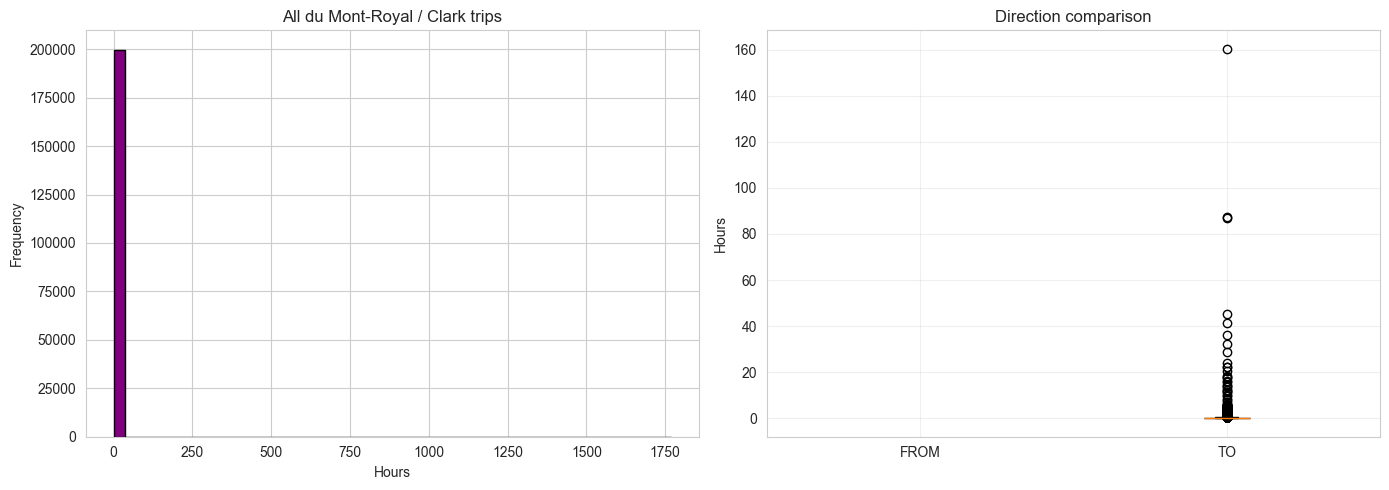

In [17]:
df_cyclo_duMontRoyal = station_specific_analysis("du Mont-Royal / Clark")  # change station name if desired

In [20]:
# create a nwe dataframe with all the parquet files and combine them into one dataframe
df_tripData = duckdb.sql("""
    SELECT *
    FROM read_parquet('../../data/**/*.parquet')
""").df()
df_tripData.head(3)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,start_station_name,start_station_district,start_station_latitude,start_station_longitude,end_station_name,end_station_district,end_station_latitude,end_station_longitude,start_time_ms,end_time_ms
0,Métro Champ-de-Mars (Viger / Sanguinet),Ville-Marie,45.510254,-73.556778,St-Antoine / Jean-Paul Riopelle,Ville-Marie,45.502941,-73.560638,1704230756167,1.704231e+12
1,Métro Place-d'Armes (Viger / St-Urbain),Ville-Marie,45.506313,-73.559669,de Maisonneuve / Aylmer (est),Ville-Marie,45.505386,-73.570435,1704232888826,1.704233e+12
2,Émile-Duployé / Sherbrooke,Le Plateau-Mont-Royal,45.527195,-73.564522,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549023,-73.591980,1704238154678,1.704239e+12


In [21]:
# convert the start_time_ms and end_time_ms to datetime format
df_tripData['start_time_ms'] = pd.to_datetime(df_tripData['start_time_ms'], unit='ms')
df_tripData['end_time_ms'] = pd.to_datetime(df_tripData['end_time_ms'], unit='ms')
df_tripData.head(3)

,start_station_name,start_station_district,start_station_latitude,start_station_longitude,end_station_name,end_station_district,end_station_latitude,end_station_longitude,start_time_ms,end_time_ms
0,Métro Champ-de-Mars (Viger / Sanguinet),Ville-Marie,45.510254,-73.556778,St-Antoine / Jean-Paul Riopelle,Ville-Marie,45.502941,-73.560638,2024-01-02 21:25:56.167,2024-01-02 21:31:46.232
1,Métro Place-d'Armes (Viger / St-Urbain),Ville-Marie,45.506313,-73.559669,de Maisonneuve / Aylmer (est),Ville-Marie,45.505386,-73.570435,2024-01-02 22:01:28.826,2024-01-02 22:08:23.502
2,Émile-Duployé / Sherbrooke,Le Plateau-Mont-Royal,45.527195,-73.564522,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549023,-73.591980,2024-01-02 23:29:14.678,2024-01-02 23:49:19.500


In [22]:
# Example: Analyze station "cyclo" inflow/outflow over time

# Assuming you have a DataFrame `rides` with columns: start_station, start_time, end_station, end_time
station = "du Mont-Royal / Clark"
# Create outflow events
out = df_tripData[df_tripData['start_station_name'] == station][['start_time_ms']].copy()
out['type'] = 'out'
out['time'] = out['start_time_ms']
# Create inflow events
inn = df_tripData[df_tripData['end_station_name'] == station][['end_time_ms']].copy()
inn['type'] = 'in'
inn['time'] = inn['end_time_ms']

# Combine, sort, and compute net change: +1 for in, -1 for out
events = pd.concat([out[['time','type']], inn[['time','type']]], ignore_index=True)
events = events.sort_values('time').reset_index(drop=True)
events['delta'] = events['type'].map({'in': 1, 'out': -1})
events['cumulative'] = events['delta'].cumsum()

In [32]:
events.head(2)

,type,delta,cumulative
time,,,
2024-01-01 06:20:15.076,out,-1,-1
2024-01-01 06:34:00.988,out,-1,-2


/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_15379/232654918.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = events.resample('H').agg({


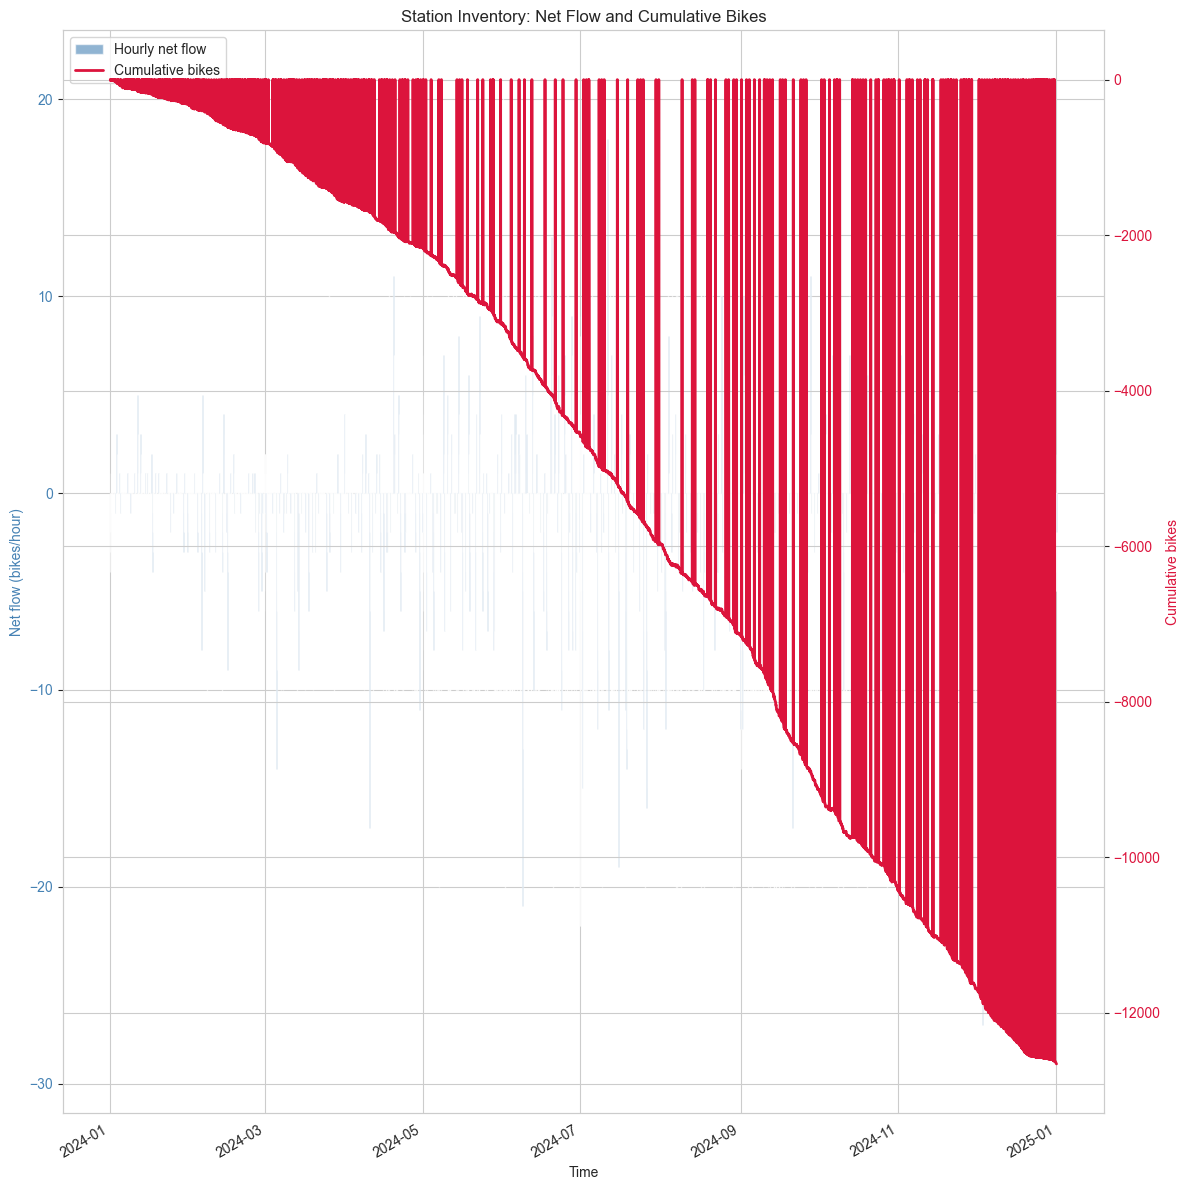

In [ ]:
station ='du Mont-Royal / Clark'

# Assuming your DataFrame is named `events` with datetime index
# Resample to a regular frequency (e.g., hourly) for smoother plotting
hourly = events.resample('H').agg({
    'delta': 'sum',          # net bikes per hour
    'cumulative': 'last'     # cumulative at end of hour
}).fillna(0)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 12))

# Plot delta as bars on primary axis
ax1.bar(hourly.index, hourly['delta'], width=0.02, color='steelblue', alpha=0.6, label='Hourly net flow')
ax1.set_xlabel('Time')
ax1.set_ylabel('Net flow (bikes/hour)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Create secondary axis sharing same x-axis
ax2 = ax1.twinx()
# Plot cumulative as line on secondary axis
ax2.plot(hourly.index, hourly['cumulative'], color='crimson', linewidth=2, label='Cumulative bikes')
ax2.set_ylabel('Cumulative bikes', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Optional: add legends (combine from both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Improve x-axis date formatting
fig.autofmt_xdate()
plt.title('Station Inventory: Net Flow and Cumulative Bikes')
plt.tight_layout()
plt.show()

In [37]:
"""interpretation of the plot above
- The blue bars represent the net flow of bikes at the station per hour. 
Positive bars indicate more bikes arriving than leaving (inflow), 
while negative bars indicate more bikes leaving than arriving (outflow).
- The red line represents the cumulative number of bikes at the station over time. 
It starts at zero and increases with inflows and decreases with outflows.
- By analyzing the plot, you can identify patterns such as peak hours of usage, 
times when the station tends to be empty or full, and how the inventory changes throughout the day or week. For example, you might see a surge in inflows in the morning as people return bikes, followed by outflows in the evening as people take bikes for their commute.
- This type of analysis can help in understanding station usage and planning for bike redistribution to ensure availability for users."""

'interpretation of the plot above\n- The blue bars represent the net flow of bikes at the station per hour. \nPositive bars indicate more bikes arriving than leaving (inflow), \nwhile negative bars indicate more bikes leaving than arriving (outflow).\n- The red line represents the cumulative number of bikes at the station over time. \nIt starts at zero and increases with inflows and decreases with outflows.\n- By analyzing the plot, you can identify patterns such as peak hours of usage, \ntimes when the station tends to be empty or full, and how the inventory changes throughout the day or week. For example, you might see a surge in inflows in the morning as people return bikes, followed by outflows in the evening as people take bikes for their commute.\n- This type of analysis can help in understanding station usage and planning for bike redistribution to ensure availability for users.'

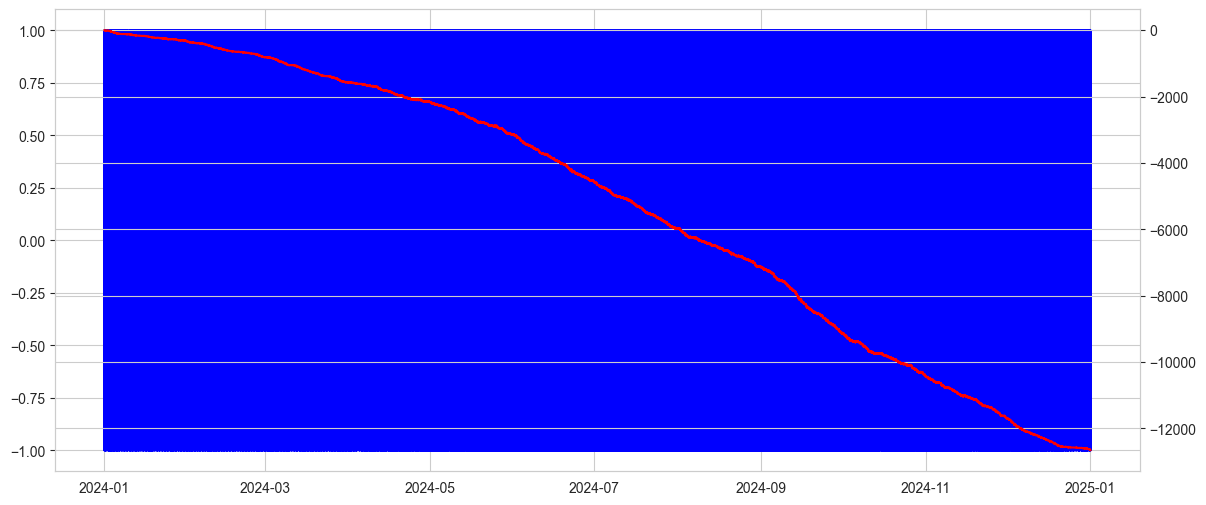

In [36]:
# plotting on raw data
fig, ax1 = plt.subplots()
ax1.step(events.index, events['delta'], where='post', color='blue', label='delta')
ax2 = ax1.twinx()
ax2.plot(events.index, events['cumulative'], color='red', label='cumulative')

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_15379/2975082413.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = events.resample('H').agg({


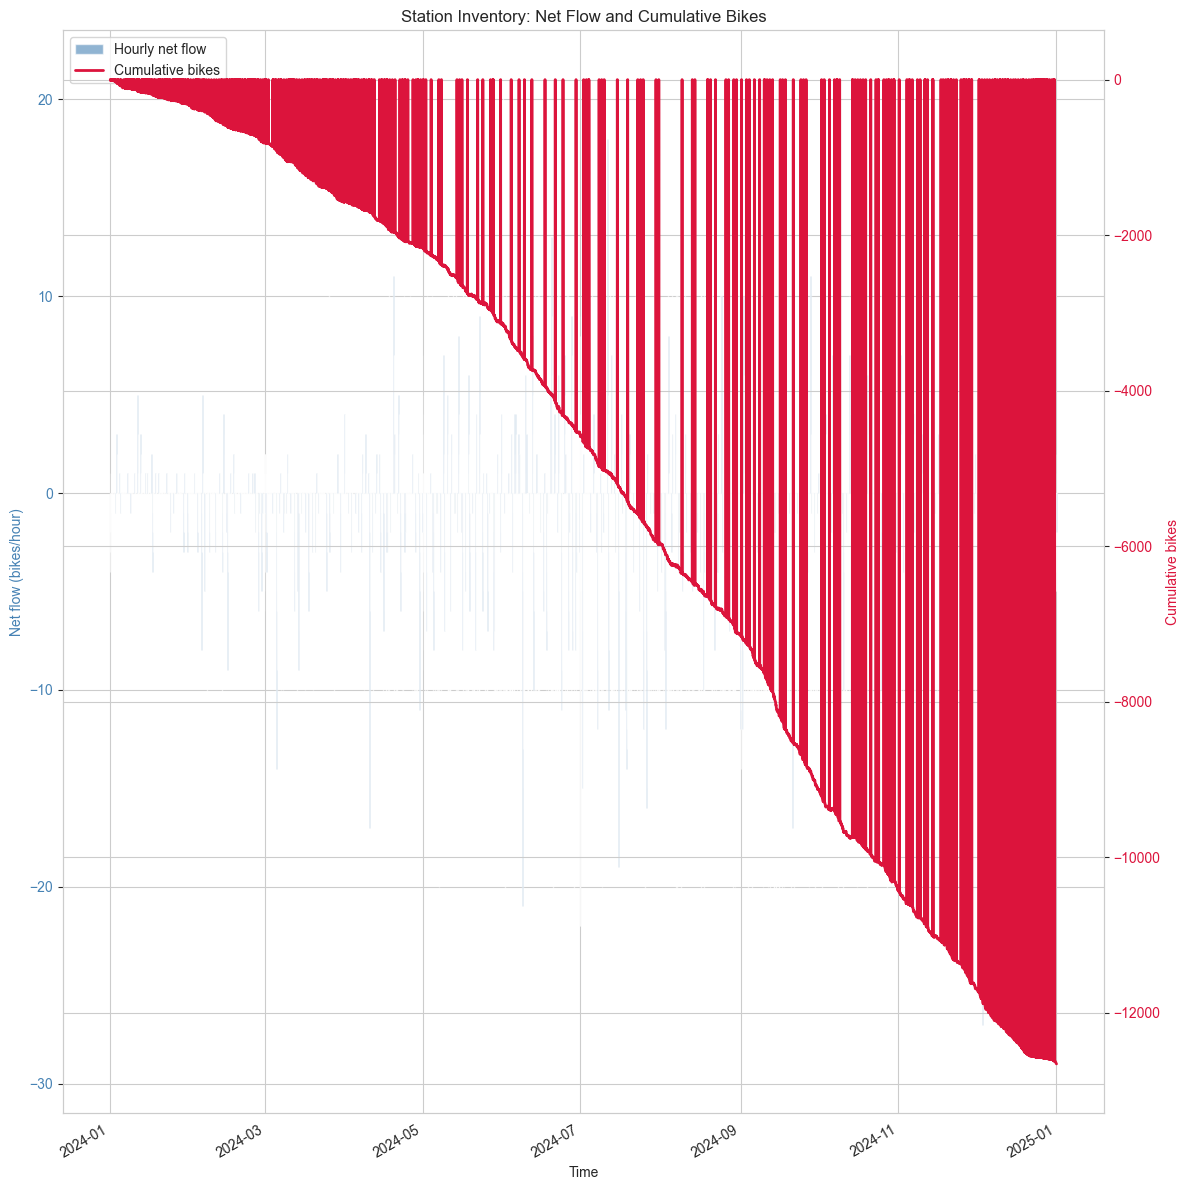

In [38]:
station ='Métro Mont-Royal (Utilités publiques / Rivard) '

# Resample to a regular frequency (e.g., hourly) for smoother plotting
hourly = events.resample('H').agg({
    'delta': 'sum',          # net bikes per hour
    'cumulative': 'last'     # cumulative at end of hour
}).fillna(0)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 12))

# Plot delta as bars on primary axis
ax1.bar(hourly.index, hourly['delta'], width=0.02, color='steelblue', alpha=0.6, label='Hourly net flow')
ax1.set_xlabel('Time')
ax1.set_ylabel('Net flow (bikes/hour)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Create secondary axis sharing same x-axis
ax2 = ax1.twinx()
# Plot cumulative as line on secondary axis
ax2.plot(hourly.index, hourly['cumulative'], color='crimson', linewidth=2, label='Cumulative bikes')
ax2.set_ylabel('Cumulative bikes', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Optional: add legends (combine from both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Improve x-axis date formatting
fig.autofmt_xdate()
plt.title('Station Inventory: Net Flow and Cumulative Bikes')
plt.tight_layout()
plt.show()

In [23]:
""" hourly net flow aggregates """
# Set time as index, resample to hourly
events.set_index('time', inplace=True)
hourly_net = events['delta'].resample('H').sum().fillna(0)
hourly_cum = hourly_net.cumsum()

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_15379/350761095.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_net = events['delta'].resample('H').sum().fillna(0)


In [1]:
# print the list of top 5 stations with most connected routes (hubs)
print("\nTop 5 most connected stations (hubs):")
for _, row in df_hubs.head(5).iterrows():
    print(f"{row['start_station_name']} ({row['start_station_district']}): {row['unique_destinations']} unique destinations, {row['total_trips_out']} total trips out") 
    


Top 5 most connected stations (hubs):


NameError: name 'df_hubs' is not defined